In [197]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [199]:
zip_path = "/content/drive/MyDrive/ML learning/archive (11).zip"

In [200]:
import zipfile
import os

extract_folder = "/content/student_dataset"
os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

extract_folder


'/content/student_dataset'

In [201]:
import os
os.listdir(extract_folder)


['StressLevelDataset.csv', 'Stress_Dataset.csv']

In [202]:
import pandas as pd

df1 = pd.read_csv(extract_folder + "/StressLevelDataset.csv")
df2 = pd.read_csv(extract_folder + "/Stress_Dataset.csv")

print("DF1 Shape:", df1.shape)
print("DF2 Shape:", df2.shape)

print(df1)
print(df2)


DF1 Shape: (1100, 21)
DF2 Shape: (843, 26)
      anxiety_level  self_esteem  mental_health_history  depression  headache  \
0                14           20                      0          11         2   
1                15            8                      1          15         5   
2                12           18                      1          14         2   
3                16           12                      1          15         4   
4                16           28                      0           7         2   
...             ...          ...                    ...         ...       ...   
1095             11           17                      0          14         3   
1096              9           12                      0           8         0   
1097              4           26                      0           3         1   
1098             21            0                      1          19         5   
1099             18            6                      1          1

In [203]:
print(df1.columns)
print(df2.columns)


Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')
Index(['Gender', 'Age', 'Have you recently experienced stress in your life?',
       'Have you noticed a rapid heartbeat or palpitations?',
       'Have you been dealing with anxiety or tension recently?',
       'Do you face any sleep problems or difficulties falling asleep?',
       'Have you been dealing with anxiety or tension recently?.1',
       'Have you been getting headaches more often than usual?',
       'Do you get irritated easily?',
       'Do you have trouble concentrating on your academic tasks?',
       'Have you been feeli

In [204]:
df = df1.copy()


In [205]:
print(df)

      anxiety_level  self_esteem  mental_health_history  depression  headache  \
0                14           20                      0          11         2   
1                15            8                      1          15         5   
2                12           18                      1          14         2   
3                16           12                      1          15         4   
4                16           28                      0           7         2   
...             ...          ...                    ...         ...       ...   
1095             11           17                      0          14         3   
1096              9           12                      0           8         0   
1097              4           26                      0           3         1   
1098             21            0                      1          19         5   
1099             18            6                      1          15         3   

      blood_pressure  sleep

In [206]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [207]:
df = df.replace(' ?', np.nan)
df = df.replace('?', np.nan)


In [208]:
print(df.isna())

      anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             False        False                  False       False     False   
1             False        False                  False       False     False   
2             False        False                  False       False     False   
3             False        False                  False       False     False   
4             False        False                  False       False     False   
...             ...          ...                    ...         ...       ...   
1095          False        False                  False       False     False   
1096          False        False                  False       False     False   
1097          False        False                  False       False     False   
1098          False        False                  False       False     False   
1099          False        False                  False       False     False   

      blood_pressure  sleep

In [209]:
print(df.isnull().sum())

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64


In [210]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [211]:
print(df.describe())

       anxiety_level  self_esteem  mental_health_history   depression  \
count    1100.000000  1100.000000            1100.000000  1100.000000   
mean       11.063636    17.777273               0.492727    12.555455   
std         6.117558     8.944599               0.500175     7.727008   
min         0.000000     0.000000               0.000000     0.000000   
25%         6.000000    11.000000               0.000000     6.000000   
50%        11.000000    19.000000               0.000000    12.000000   
75%        16.000000    26.000000               1.000000    19.000000   
max        21.000000    30.000000               1.000000    27.000000   

          headache  blood_pressure  sleep_quality  breathing_problem  \
count  1100.000000     1100.000000    1100.000000        1100.000000   
mean      2.508182        2.181818       2.660000           2.753636   
std       1.409356        0.833575       1.548383           1.400713   
min       0.000000        1.000000       0.000000     

In [212]:
print("Unique values in each column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values in each column:
anxiety_level : 22
self_esteem : 31
mental_health_history : 2
depression : 28
headache : 6
blood_pressure : 3
sleep_quality : 6
breathing_problem : 6
noise_level : 6
living_conditions : 6
safety : 6
basic_needs : 6
academic_performance : 6
study_load : 6
teacher_student_relationship : 6
future_career_concerns : 6
social_support : 4
peer_pressure : 6
extracurricular_activities : 6
bullying : 6
stress_level : 3


In [213]:
for col in df.columns:
    print("Value counts for ")
    print(df[col].value_counts())
    print("--------------------------------------------------")


Value counts for 
anxiety_level
13    67
10    63
19    61
21    61
9     60
12    56
18    55
11    54
6     52
7     51
14    51
15    51
3     48
17    47
1     46
2     46
16    45
8     44
5     40
20    40
4     33
0     29
Name: count, dtype: int64
--------------------------------------------------
Value counts for 
self_esteem
25    83
30    60
27    59
26    58
28    53
29    52
15    50
23    45
17    40
21    38
16    37
11    37
20    36
13    32
6     31
24    30
1     28
7     28
19    28
22    27
8     26
3     25
9     25
0     24
18    24
12    23
2     21
14    21
10    21
4     19
5     19
Name: count, dtype: int64
--------------------------------------------------
Value counts for 
mental_health_history
0    558
1    542
Name: count, dtype: int64
--------------------------------------------------
Value counts for 
depression
10    66
12    63
13    63
14    57
8     49
3     47
9     46
11    46
0     44
5     43
7     42
18    41
2     36
22    36
27    36
1     36

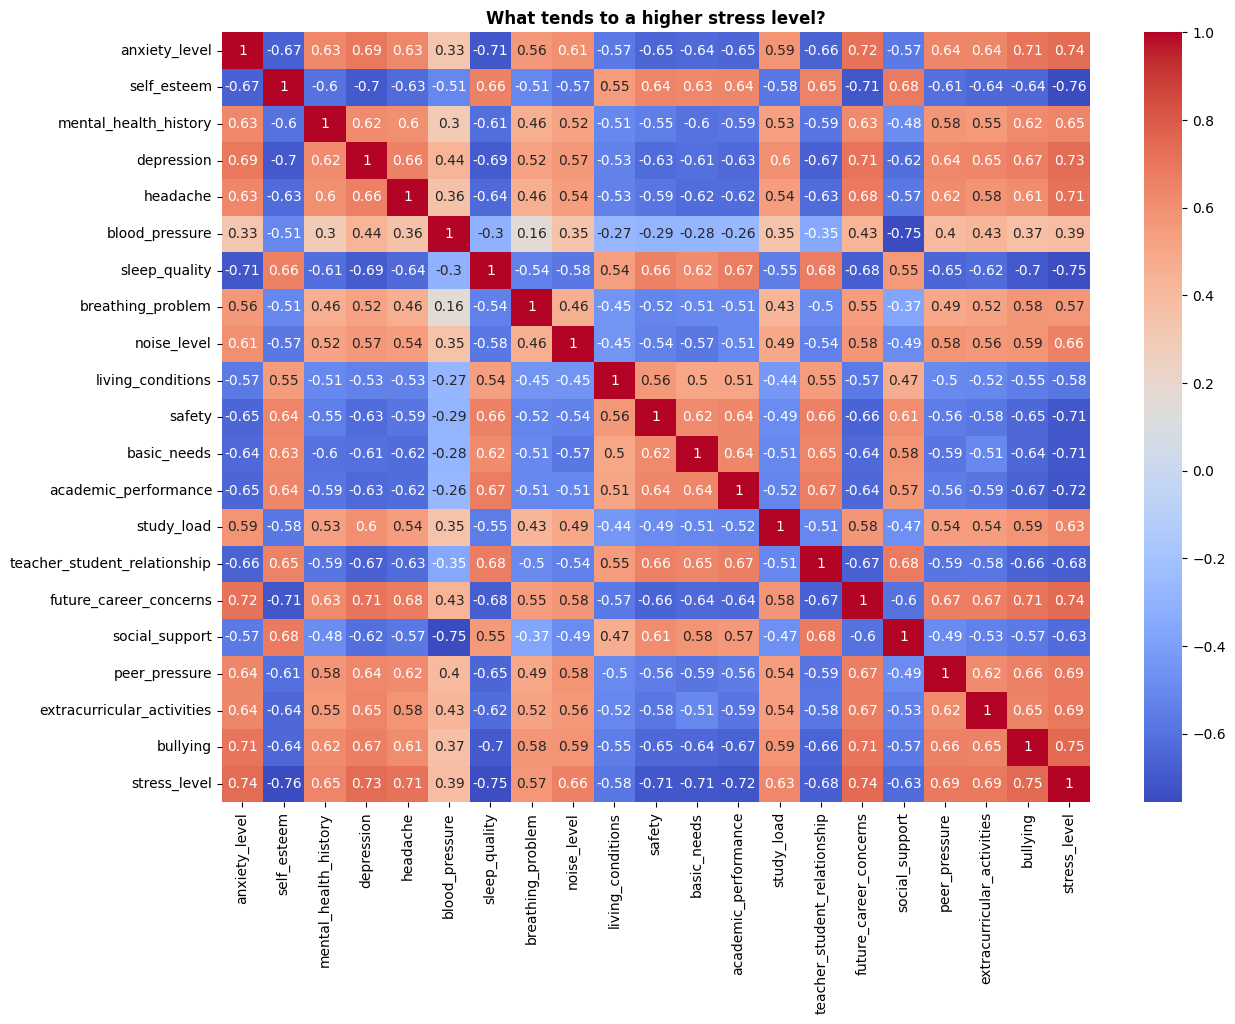

In [214]:
correlation_df= df.corr()

# Create a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(data=correlation_df, annot=True, cmap='coolwarm')
plt.title("What tends to a higher stress level?", fontweight='bold')
plt.show()

Average anxiety of students in this dataset is  11.06


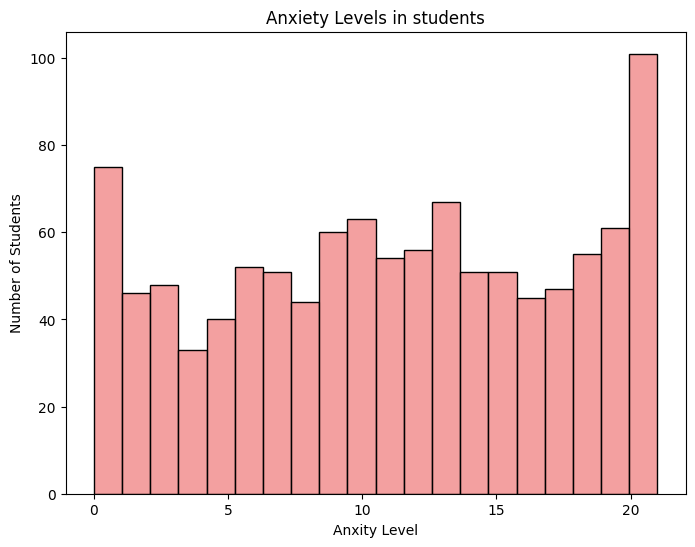

In [215]:
average_anxiety = df['anxiety_level'].mean().round(2)
print('Average anxiety of students in this dataset is ', average_anxiety)

# Visualizing anxiety levels in students
plt.figure(figsize=(8,6))
ax = sns.histplot(data=df, x='anxiety_level', bins=20, color='lightcoral')
plt.title('Anxiety Levels in students')
plt.xlabel('Anxity Level')
plt.ylabel('Number of Students')
plt.show()


Target distribution:
 stress_level
0    373
1    358
2    369
Name: count, dtype: int64


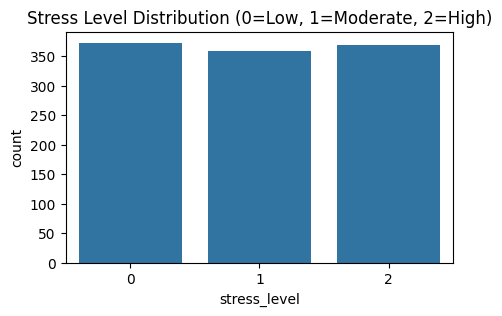

In [216]:
print("\nTarget distribution:\n", df['stress_level'].value_counts().sort_index())
plt.figure(figsize=(5,3))
sns.countplot(x='stress_level', data=df)
plt.title('Stress Level Distribution (0=Low, 1=Moderate, 2=High)')
plt.show()

In [217]:
from sklearn.model_selection import train_test_split
X = df.drop('stress_level', axis=1)
y = df['stress_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [218]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (1100, 20)
Shape of y: (1100,)


In [219]:
print("Class counts:\n", y.value_counts().sort_index())

Class counts:
 stress_level
0    373
1    358
2    369
Name: count, dtype: int64


In [220]:
joblib.dump(X_train.columns.tolist(), 'student_columns.pkl')
print("Saved feature column names to student_columns.pkl")

Saved feature column names to student_columns.pkl


In [221]:
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (880, 20)
Testing features shape: (220, 20)
Training target shape: (880,)
Testing target shape: (220,)


In [222]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'student_scaler.pkl')
print("Scaler saved successfully student_scaler.pkl")

Scaler saved successfully student_scaler.pkl


In [223]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)


LogisticRegression()

In [224]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8818181818181818

Confusion Matrix:
 [[63  5  6]
 [ 3 66  3]
 [ 7  2 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86        74
           1       0.90      0.92      0.91        72
           2       0.88      0.88      0.88        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



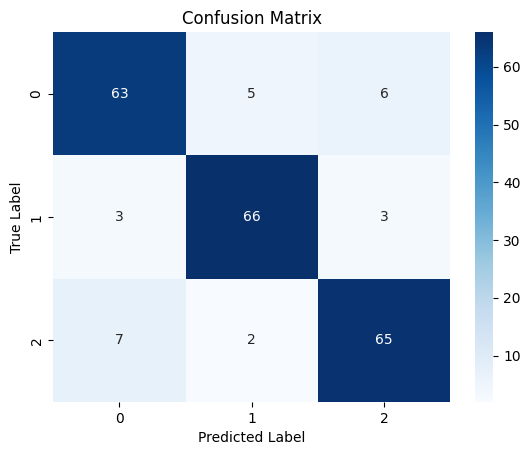

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


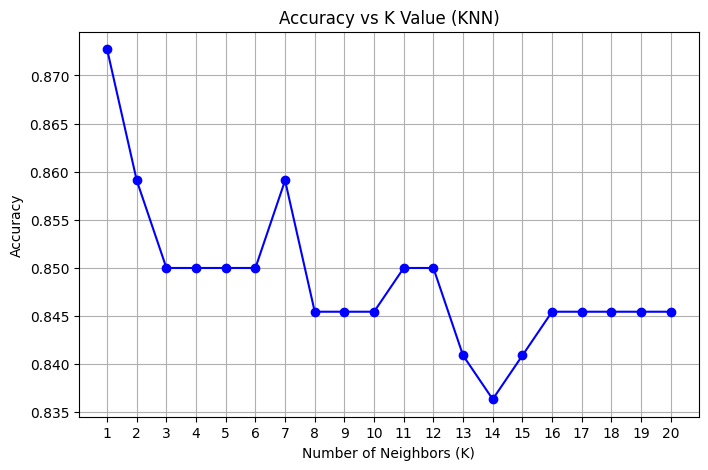

In [226]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred)
    accuracy_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), accuracy_scores, marker='o', color='blue')
plt.title("Accuracy vs K Value (KNN)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(range(1, 21))
plt.show()




In [227]:
best_k = accuracy_scores.index(max(accuracy_scores)) + 1
print("Best K value:", best_k)
print("Highest Accuracy:", max(accuracy_scores))

Best K value: 1
Highest Accuracy: 0.8727272727272727


In [228]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


KNN Classifier Evaluation:
Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82        74
           1       0.90      0.92      0.91        72
           2       0.81      0.82      0.82        74

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85      0.85       220


Confusion Matrix:
 [[60  3 11]
 [ 3 66  3]
 [ 9  4 61]]


In [229]:
from sklearn.tree import DecisionTreeClassifier

accuracy_scores = []

for depth in range(1, 21):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)  # Use scaled data
    y_pred = dt.predict(X_test_scaled)  # Use scaled data
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

# ... rest of plotting code stays same ...

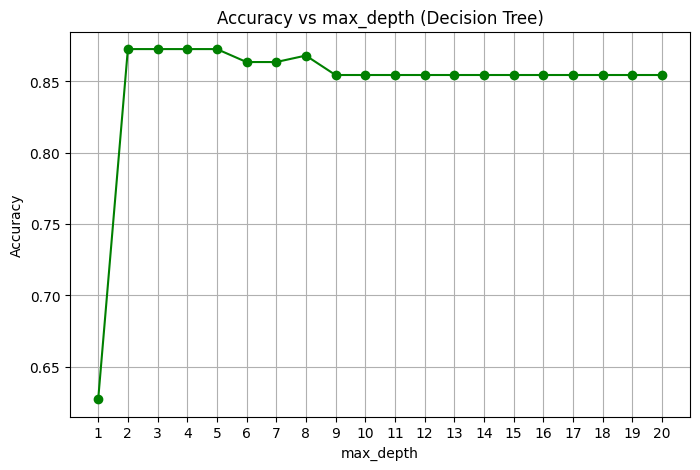

Best max_depth: 2
Highest Accuracy: 0.8727272727272727


In [230]:

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), accuracy_scores, marker='o', linestyle='-', color='green')
plt.title("Accuracy vs max_depth (Decision Tree)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(range(1, 21))
plt.show()

best_depth = accuracy_scores.index(max(accuracy_scores)) + 1
print("Best max_depth:", best_depth)
print("Highest Accuracy:", max(accuracy_scores))



In [231]:
final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_tree.fit(X_train_scaled, y_train)
y_pred_tree = final_tree.predict(X_test_scaled)

print("Final Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Final Decision Tree Results:
Accuracy: 0.8727272727272727
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.81      0.85        74
           1       1.00      0.89      0.94        72
           2       0.77      0.92      0.84        74

    accuracy                           0.87       220
   macro avg       0.89      0.87      0.88       220
weighted avg       0.88      0.87      0.87       220

Confusion Matrix:
 [[60  0 14]
 [ 2 64  6]
 [ 6  0 68]]


In [232]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

accuracy_scores = []

for n in range(10, 110, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_scaled, y_train)  # Use scaled data
    y_pred = rf.predict(X_test_scaled)  # Use scaled data
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

# ... plotting code stays same ...

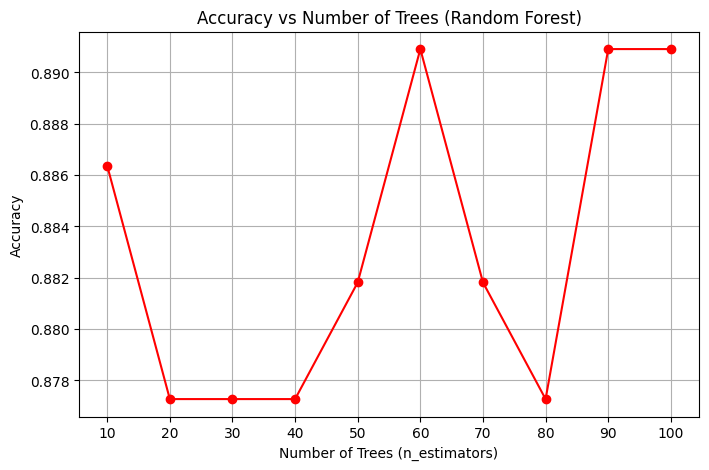

Best n_estimators: 60
Highest Accuracy: 0.8909090909090909


In [233]:
plt.figure(figsize=(8,5))
plt.plot(range(10, 110, 10), accuracy_scores, marker='o', linestyle='-', color='red')
plt.title("Accuracy vs Number of Trees (Random Forest)")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(range(10, 110, 10))
plt.show()

best_n = range(10, 110, 10)[accuracy_scores.index(max(accuracy_scores))]
print("Best n_estimators:", best_n)
print("Highest Accuracy:", max(accuracy_scores))



In [234]:
final_rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
final_rf.fit(X_train_scaled, y_train)  # Use scaled data
y_pred_rf = final_rf.predict(X_test_scaled)  # Use scaled data

print("Final Random Forest Model Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



Final Random Forest Model Results:
Accuracy: 0.8909090909090909
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87        74
           1       0.91      0.93      0.92        72
           2       0.87      0.91      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220

Confusion Matrix:
 [[62  5  7]
 [ 2 67  3]
 [ 5  2 67]]


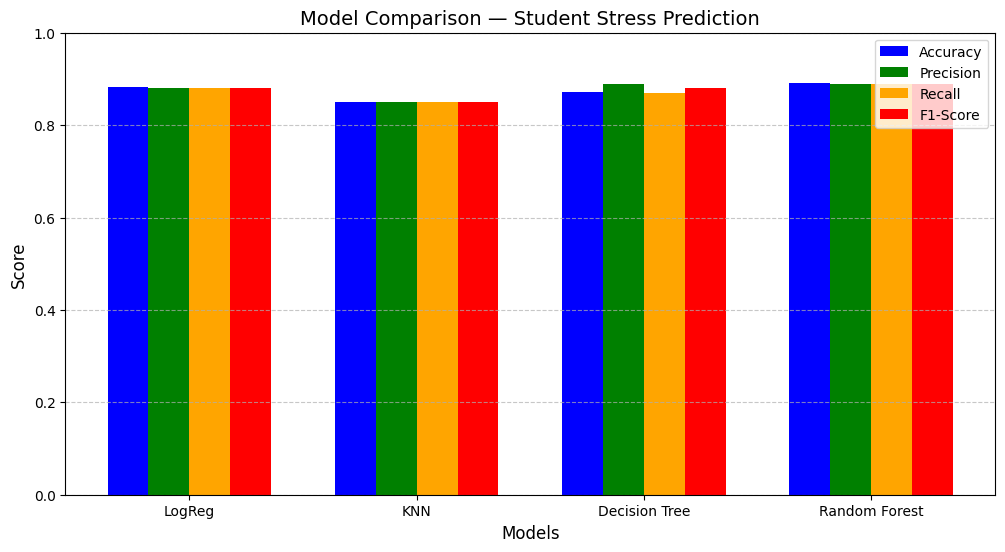

In [235]:
import numpy as np
import matplotlib.pyplot as plt

models   = ['LogReg', 'KNN', 'Decision Tree', 'Random Forest']

# Updated metrics (macro averages + accuracy)
accuracy = [0.8818, 0.8500, 0.8727, 0.8909]
precision= [0.88,   0.85,   0.89,   0.89]
recall   = [0.88,   0.85,   0.87,   0.89]
f1       = [0.88,   0.85,   0.88,   0.89]

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(12,6))
plt.bar(x - width*1.5, accuracy,  width, label='Accuracy',  color='blue')
plt.bar(x - width/2,  precision, width, label='Precision', color='green')
plt.bar(x + width/2,  recall,    width, label='Recall',    color='orange')
plt.bar(x + width*1.5,f1,        width, label='F1-Score',  color='red')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Comparison — Student Stress Prediction', fontsize=14)
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [236]:
proba = final_rf.predict_proba(X_test_scaled)
high_class_index = list(final_rf.classes_).index(2)

df_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "P(HighStress)": proba[:, high_class_index]
})

df_results["Stress_Score"] = (df_results["P(HighStress)"] * 100).round(2)

print(df_results.head(10))

   Actual  Predicted  P(HighStress)  Stress_Score
0       0          0       0.000000          0.00
1       0          0       0.000000          0.00
2       2          2       1.000000        100.00
3       2          2       1.000000        100.00
4       0          2       0.516667         51.67
5       0          0       0.000000          0.00
6       2          2       1.000000        100.00
7       0          1       0.383333         38.33
8       1          1       0.000000          0.00
9       0          0       0.350000         35.00


In [237]:
def interpret(score):
    if score < 40:
        return "Low Stress - You're doing great! Keep up healthy habits. 😊"
    elif 40 <= score <= 70:
        return "Moderate Stress - Consider stress management techniques or talking to someone. 🤔"
    else:
        return "High Stress - Please reach out to a counselor or healthcare professional. ⚠️"

df_results["Stress_Level_Interpretation"] = df_results["Stress_Score"].apply(interpret)
df_results["Band"] = df_results["Stress_Score"].apply(
    lambda s: "Low" if s < 40 else "Moderate" if s <= 70 else "High"
)

print(df_results.head(10))

   Actual  Predicted  P(HighStress)  Stress_Score  \
0       0          0       0.000000          0.00   
1       0          0       0.000000          0.00   
2       2          2       1.000000        100.00   
3       2          2       1.000000        100.00   
4       0          2       0.516667         51.67   
5       0          0       0.000000          0.00   
6       2          2       1.000000        100.00   
7       0          1       0.383333         38.33   
8       1          1       0.000000          0.00   
9       0          0       0.350000         35.00   

                         Stress_Level_Interpretation      Band  
0  Low Stress - You're doing great! Keep up healt...       Low  
1  Low Stress - You're doing great! Keep up healt...       Low  
2  High Stress - Please reach out to a counselor ...      High  
3  High Stress - Please reach out to a counselor ...      High  
4  Moderate Stress - Consider stress management t...  Moderate  
5  Low Stress - You're doi

In [238]:
# Save all artifacts needed for deployment
joblib.dump(final_rf, 'student_stress_rf_model.pkl')
joblib.dump(X_train.columns.tolist(), 'student_columns.pkl')
joblib.dump(scaler, 'student_scaler.pkl')
joblib.dump({'low':(0,40),'moderate':(40,70),'high':(70,100)}, 'student_stress_meta.pkl')
print("Saved: model, columns, scaler, meta")

Saved: model, columns, scaler, meta


In [239]:
def predict_scores(df_like):
    """
    Predicts stress scores for multiple students at once.
    Input: DataFrame with same columns as training data
    Output: DataFrame with predictions
    """
    cols = joblib.load('student_columns.pkl')
    model = joblib.load('student_stress_rf_model.pkl')
    scaler = joblib.load('student_scaler.pkl')

    X_scaled = scaler.transform(df_like[cols])

    hi = list(model.classes_).index(2)
    P = model.predict_proba(X_scaled)[:, hi]
    S = (P * 100).round(2)
    C = model.predict(X_scaled)
    B = ["Low" if s < 40 else "Moderate" if s <= 70 else "High" for s in S]
    M = [interpret(s) for s in S]

    return pd.DataFrame({
        "predicted_class": C,
        "p_high": P,
        "stress_score": S,
        "band": B,
        "message": M
    }, index=df_like.index)

print("\n🧪 Testing prediction function:")
test_results = predict_scores(X_test.head(5))
print(test_results)


🧪 Testing prediction function:
      predicted_class    p_high  stress_score      band  \
150                 0  0.000000          0.00       Low   
582                 0  0.000000          0.00       Low   
450                 2  1.000000        100.00      High   
616                 2  1.000000        100.00      High   
1090                2  0.516667         51.67  Moderate   

                                                message  
150   Low Stress - You're doing great! Keep up healt...  
582   Low Stress - You're doing great! Keep up healt...  
450   High Stress - Please reach out to a counselor ...  
616   High Stress - Please reach out to a counselor ...  
1090  Moderate Stress - Consider stress management t...  


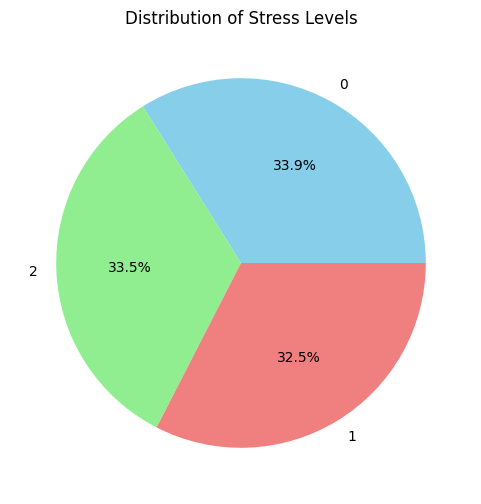

In [240]:
stress_level_counts = df['stress_level'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(stress_level_counts, labels=stress_level_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Distribution of Stress Levels')
plt.show()

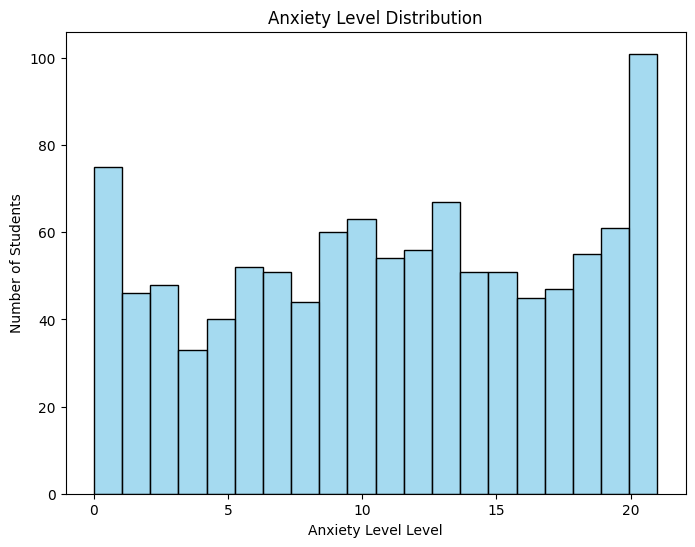

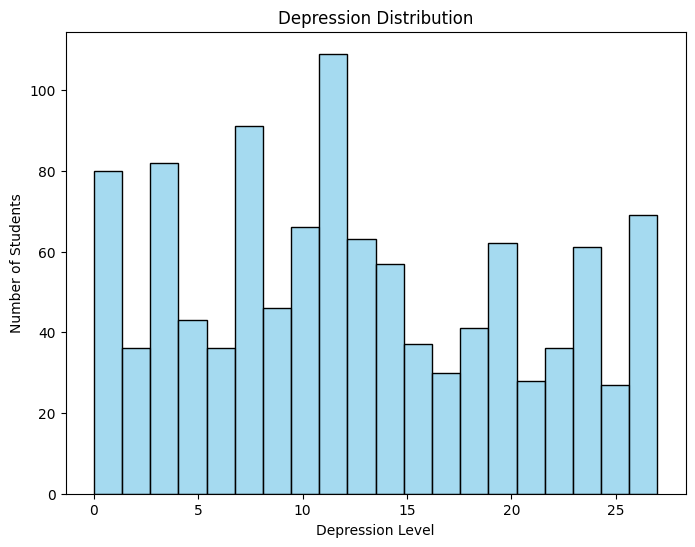

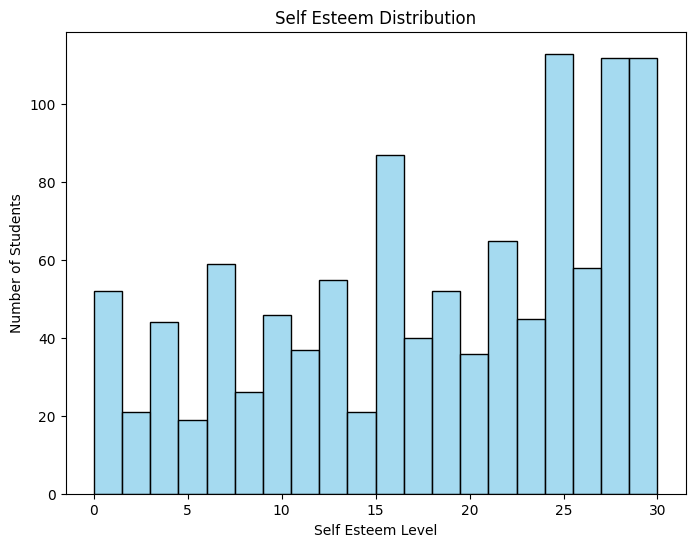

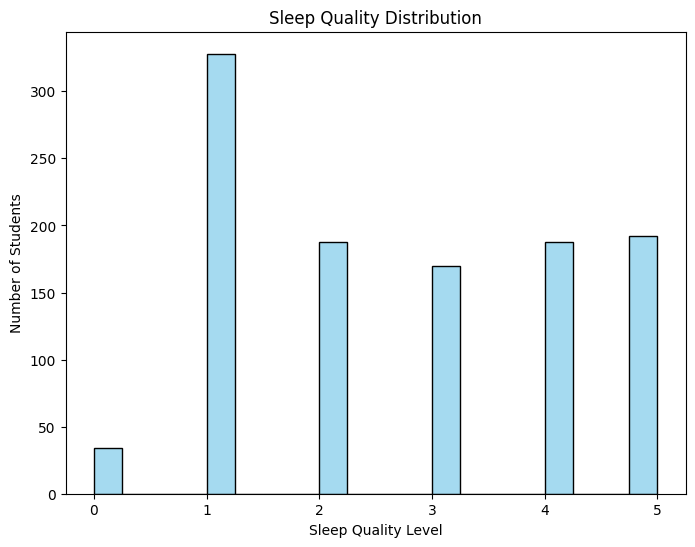

In [241]:
key_features = ['anxiety_level', 'depression', 'self_esteem', 'sleep_quality']

for feature in key_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=feature, bins=20, color='skyblue')
    plt.title(f'{feature.replace("_", " ").title()} Distribution')
    plt.xlabel(f'{feature.replace("_", " ").title()} Level')
    plt.ylabel('Number of Students')
    plt.show()

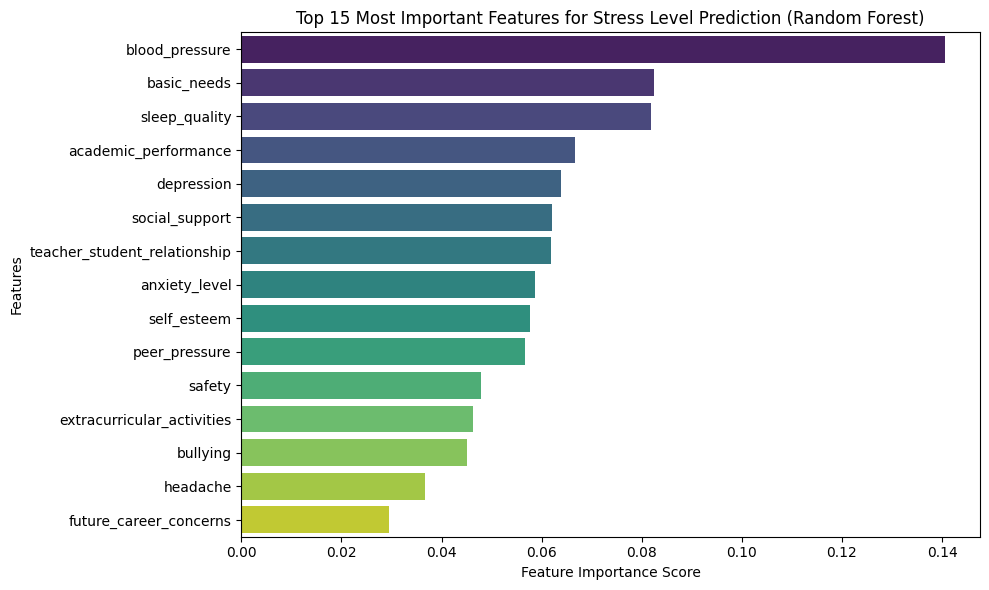

In [242]:
importances = final_rf.feature_importances_

feature_importances = pd.Series(importances, index=X_train.columns)

feature_importances = feature_importances.sort_values(ascending=False)

top_n = 15
top_features = feature_importances.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)

plt.title(f'Top {top_n} Most Important Features for Stress Level Prediction (Random Forest)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()